# Task 1: Exploratory Data Analysis (EDA)

## Bank Marketing Term Deposit Prediction

**Objective:** This notebook explores the bank marketing dataset to understand the structure, data quality, target distribution, feature patterns, and modelling risks before building a prediction pipeline.

The target variable is `y`, which shows whether a client subscribed to a term deposit after a marketing contact.

This EDA focuses on four questions:

1. What does the dataset contain?
2. Are there data quality issues that need to be handled?
3. Which variables appear related to term deposit subscription?
4. What risks or assumptions should be considered before modelling?

## Table of Contents

This overview lists the main notebook sections in order. Internal notebook links are intentionally not used because the current notebook viewer does not navigate reliably with anchor links.

1. Notebook Setup and Data Load
2. Data Quality and Target Distribution
3. Numerical Feature Analysis and Target Comparisons
4. Categorical Feature Analysis and Interactions
5. Statistical Associations and Correlation Review
6. Leakage and Modelling Risks
7. Conclusions and Modelling Strategy

The four guiding questions map to the notebook sections as follows:

- **What does the dataset contain?** Sections 1 and 2 load the data, inspect the columns, and explain the target variable.
- **Are there data quality issues that need to be handled?** Section 2 checks missing values, hidden `unknown` values, duplicates, and target imbalance.
- **Which variables appear related to term deposit subscription?** Sections 3, 4, and 5 compare numerical, categorical, interaction, economic, and statistical patterns against the target.
- **What risks or assumptions should be considered before modelling?** Sections 6 and 7 summarise leakage risks, special handling for `pdays`, and modelling recommendations.


### Section 1: Notebook Setup and Data Load

In this section, I import the Python libraries needed for data analysis and visualisation.

In [2]:
# Import libraries and set up environment
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, mannwhitneyu

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)
sns.set_theme(style="whitegrid")

DATA_PATH = Path("../data/bank-additional-full.csv")
if not DATA_PATH.exists():
    DATA_PATH = Path("data/bank-additional-full.csv")


#### Load and Inspect the Data

The dataset has **41,188 rows** and **21 columns** and there are no missing values.

In [3]:
# Load the dataset and check its shape
df = pd.read_csv(DATA_PATH)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

The first few rows show a mix of client information, campaign contact details, previous campaign outcomes, economic indicators, and the target variable 'y'.

The dataset contains both numerical and categorical variables.

This matters because numerical variables can be summarised using statistics such as mean and median, while categorical variables need frequency counts and category-level comparisons.

In [4]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no


In [5]:
all_columns = df.columns.tolist()
all_columns

['age',
 'job',
 'marital',
 'education',
 'default',
 'housing',
 'loan',
 'contact',
 'month',
 'day_of_week',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'poutcome',
 'emp.var.rate',
 'cons.price.idx',
 'cons.conf.idx',
 'euribor3m',
 'nr.employed',
 'y']

The columns can be grouped into several broad areas:

- **Client profile:** `age`, `job`, `marital`, `education`, `default`, `housing`, `loan`
- **Current campaign:** `contact`, `month`, `day_of_week`, `duration`, `campaign`
- **Previous campaign:** `pdays`, `previous`, `poutcome`
- **Economic context:** `emp.var.rate`, `cons.price.idx`, `cons.conf.idx`, `euribor3m`, `nr.employed`
- **Target:** `y`

#### Section 1 Summary

The data loaded correctly and contains a clear binary target column, `y`.

The dataset is suitable for classification analysis because the target variable 'y' is categorical and has two possible outcomes "yes" (the client subscribed to a term deposit) and "no" (the client did not subscribe).

### Section 2: Data Quality and Target Distribution

In this section, I run a more explicit data quality review by checking standard missing values, duplicate rows, hidden missing values, and the target distribution.

Although `df.info()` in Section 1 did not show standard missing values, I repeat the missing-value check here because Section 2 is where data quality issues are formally validated. I also check for `unknown` values because they are stored as text and are not detected by normal null checks.

This is important because data quality issues and target imbalance both affect the EDA conclusions and any future machine learning model.

In [ ]:
missing_values = df.isna().sum()
missing_summary = missing_values[missing_values > 0]
duplicate_rows = df.duplicated().sum()

data_quality_summary = pd.DataFrame({
    "check": ["columns_with_standard_missing_values", "duplicate_rows"],
    "result": [len(missing_summary), duplicate_rows]
})

data_quality_summary

,check,result
0,columns_with_standard_missing_values,0
1,duplicate_rows,12


The explicit missing-value check confirms that there are no standard null values. This supports the initial `df.info()` inspection from Section 1.

There are **12 duplicate rows**. The duplicate rows represent a very small proportion of the dataset, so they are unlikely to materially affect the EDA findings. However, the decision to remove them should be made during preprocessing before model training, because duplicate records can slightly bias model learning and evaluation if they appear across train and test splits.

In [ ]:
categorical_columns = df.select_dtypes(include="object").columns
unknown_counts = df[categorical_columns].eq("unknown").sum().sort_values(ascending=False)
unknown_percent = (unknown_counts / len(df) * 100).round(2)

unknown_summary = pd.DataFrame({
    "unknown_count": unknown_counts,
    "unknown_percent": unknown_percent
})

unknown_summary[unknown_summary["unknown_count"] > 0]

,unknown_count,unknown_percent
default,8597,20.87
education,1731,4.20
housing,990,2.40
loan,990,2.40
job,330,0.80
marital,80,0.19


Several categorical columns contain `unknown` values.

The largest issue is `default`, followed by `education`, `housing`, `loan`, `job`, and `marital`.

This means the dataset has hidden missingness. I should not treat `unknown` as a normal category without thinking about it, because it may represent information that was not collected or not available.

#### Target Variable Analysis

The target variable is `y`.

`yes` means the client subscribed to a term deposit, while `no` means the client did not subscribe.

Understanding the target distribution is important because an imbalanced target affects how model performance should be measured.

In [ ]:
target_counts = df["y"].value_counts()
target_percent = (df["y"].value_counts(normalize=True) * 100).round(2)
target_summary = pd.DataFrame({
    "count": target_counts,
    "percent": target_percent
})

target_summary

,count,percent
y,,
no,36548,88.73
yes,4640,11.27


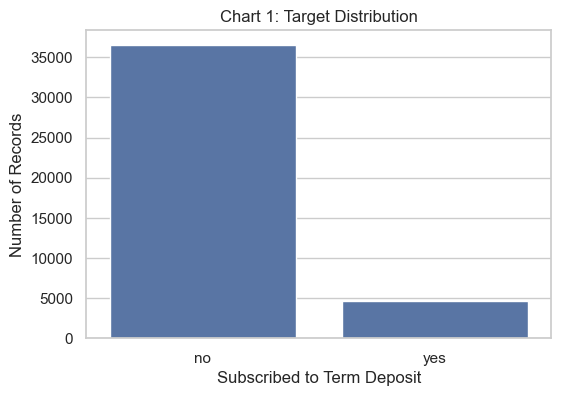

In [9]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="y", order=["no", "yes"])

plt.title("Chart 1: Target Distribution")

plt.xlabel("Subscribed to Term Deposit")

plt.ylabel("Number of Records")

plt.show()

#### How to Interpret Chart 1

The target is imbalanced:

- **88.73%** of records are `no`
- **11.27%** of records are `yes`

This matters because a model could predict `no` for every client and still achieve about 88.73% accuracy, even though it would fail to identify any actual subscribers. For future modelling, metrics such as recall, precision, F1-score, ROC-AUC, or PR-AUC will be more informative than accuracy alone.

#### Section 2 Summary

The dataset has no standard null values, but it does contain hidden missing values stored as `unknown`.

There are also 12 duplicate rows. I should decide whether to remove these during preprocessing before training the model.

For future preprocessing, I would either keep `unknown` as its own category or handle it carefully depending on the modelling method.


### Section 3: Numerical Feature Analysis and Target Comparisons

In this section, I inspect numerical variables using summary statistics and simple distribution plots, and compare key numerical features against the target.

This helps identify skewed variables, unusual values, and features that may need special preprocessing, as well as how those variables differ between subscribed and non-subscribed clients.

In [10]:
numeric_columns = df.select_dtypes(include=["int64", "float64"]).columns

df[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
age,41188.00,40.02,10.42,17.00,32.00,38.00,47.00,98.00
duration,41188.00,258.29,259.28,0.00,102.00,180.00,319.00,4918.00
campaign,41188.00,2.57,2.77,1.00,1.00,2.00,3.00,56.00
pdays,41188.00,962.48,186.91,0.00,999.00,999.00,999.00,999.00
previous,41188.00,0.17,0.49,0.00,0.00,0.00,0.00,7.00
emp.var.rate,41188.00,0.08,1.57,-3.40,-1.80,1.10,1.40,1.40
cons.price.idx,41188.00,93.58,0.58,92.20,93.08,93.75,93.99,94.77
cons.conf.idx,41188.00,-40.50,4.63,-50.80,-42.70,-41.80,-36.40,-26.90
euribor3m,41188.00,3.62,1.73,0.63,1.34,4.86,4.96,5.04
nr.employed,41188.00,5167.04,72.25,4963.60,5099.10,5191.00,5228.10,5228.10


The summary statistics show several important points:

- `age` ranges from 17 to 98, with most clients around their 30s and 40s.
- `duration` is highly spread out, with some very long call durations.
- `campaign` is skewed, meaning most clients were contacted only a few times, but a few were contacted many times.
- `pdays` has a median of 999, which is a special value meaning the client was not previously contacted, rather than a normal number of days.
- Economic variables such as `euribor3m` and `nr.employed` are numerical context variables and may be related to each other.

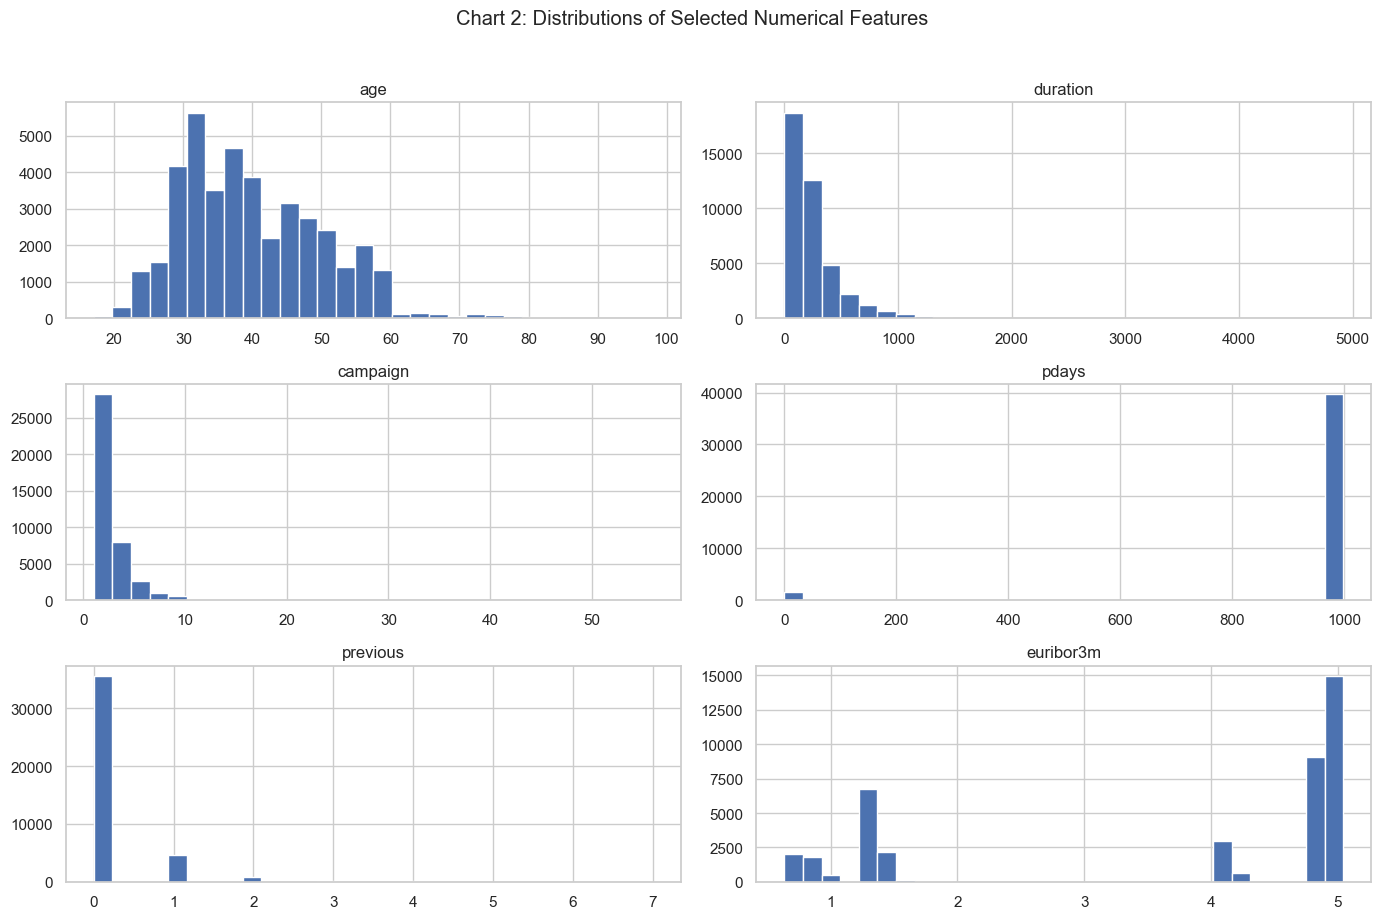

In [11]:
selected_numeric = ["age", "duration", "campaign", "pdays", "previous", "euribor3m"]

df[selected_numeric].hist(figsize=(14, 9), bins=30)

plt.suptitle("Chart 2: Distributions of Selected Numerical Features", y=1.02)

plt.tight_layout()

plt.show()

#### How to Interpret Chart 2

The histograms show that several numerical variables are not normally distributed.

`duration`, `campaign`, and `previous` are right-skewed. This means most values are small, but there are some much larger values.

`pdays` is dominated by the value 999. This needs special attention because the data dictionary states that 999 means the client was not previously contacted, not that the previous contact happened 999 days ago.

In [12]:
pdays_999_percent = (df["pdays"].eq(999).mean() * 100).round(2)

pdays_999_percent

np.float64(96.32)

**96.32%** of records have `pdays = 999`.

This confirms that `pdays` should not be treated as a normal continuous variable without adjustment, because 999 represents "not previously contacted" rather than an actual number of days. A useful future feature may be whether the client was contacted before, instead of using 999 directly as a real day value.

In [13]:
# Use the IQR rule to flag unusually low or high values in each numerical column.
outlier_summaries = []

for column in numeric_columns:
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1
    
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    outlier_count = ((df[column] < lower_bound) | (df[column] > upper_bound)).sum()
    outlier_percent = outlier_count / len(df) * 100
    
    outlier_summaries.append({
        "column": column,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "outlier_count": outlier_count,
        "outlier_percent": outlier_percent,
        "minimum": df[column].min(),
        "maximum": df[column].max()
    })

outlier_summary = pd.DataFrame(outlier_summaries).sort_values("outlier_percent", ascending=False)
outlier_summary

,column,lower_bound,upper_bound,outlier_count,outlier_percent,min_value,max_value
4,previous,0.00,0.00,5625,13.66,0.00,7.00
1,duration,-223.50,644.50,2963,7.19,0.00,4918.00
2,campaign,-2.00,6.00,2406,5.84,1.00,56.00
3,pdays,999.00,999.00,1515,3.68,0.00,999.00
0,age,9.50,69.50,469,1.14,17.00,98.00
7,cons.conf.idx,-52.15,-26.95,447,1.09,-50.80,-26.90
5,emp.var.rate,-6.60,6.20,0,0.00,-3.40,1.40
6,cons.price.idx,91.70,95.37,0,0.00,92.20,94.77
8,euribor3m,-4.08,10.39,0,0.00,0.63,5.04
9,nr.employed,4905.60,5421.60,0,0.00,4963.60,5228.10


#### Outlier Check Using IQR Bounds

The IQR method flags values that fall far below or above the middle 50% of each numerical feature.

This check confirms that several numerical variables contain extreme values. `campaign`, `duration`, and `previous` have high-end outliers because most clients have small values but a small number have much larger values. `age` also has some high values, with a maximum age of 98, so it should be reviewed but not automatically removed because older clients can be valid observations.

For EDA, these outliers are important to identify. In Task 2, the modelling pipeline can decide whether to cap, transform, keep, or use models that are robust to these values.

#### Numerical Features Compared with Target

In this section, I compare selected numerical variables between clients who subscribed and clients who did not.

Boxplots are useful here because they show the median, spread, and outliers for each target group. I also include a focused comparison of all economic indicators because they may be important predictors in this dataset.

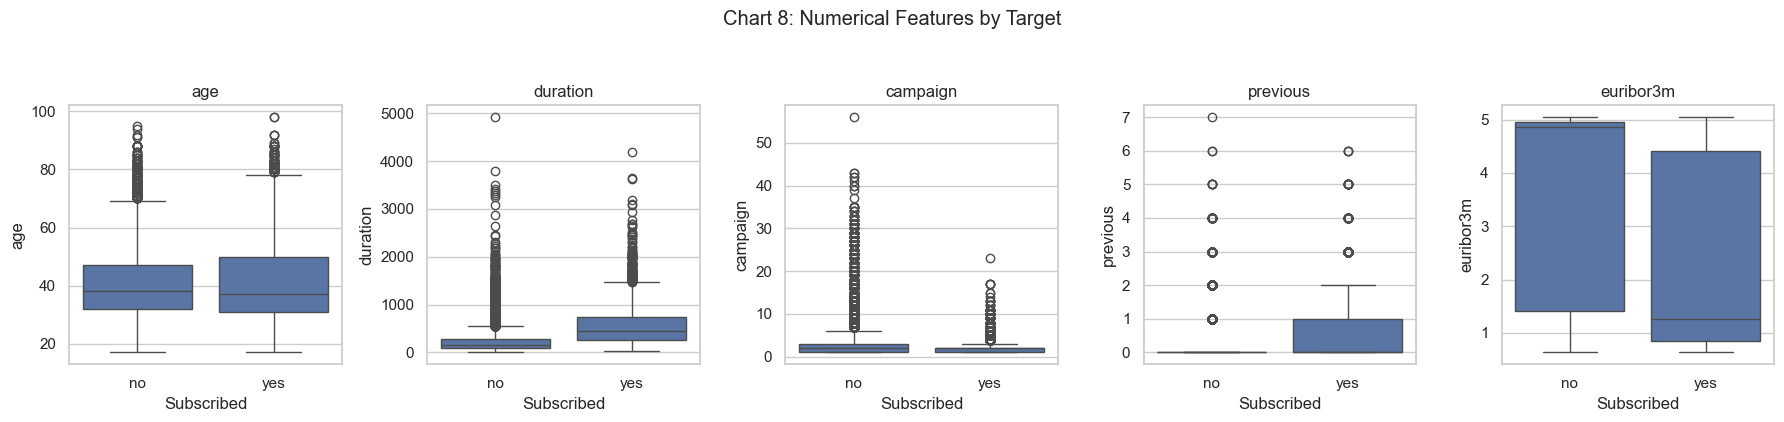

In [21]:
compare_numeric = ["age", "duration", "campaign", "previous", "euribor3m"]
fig, axes = plt.subplots(1, len(compare_numeric), figsize=(18, 4))

# Repeat the same boxplot comparison for each selected numerical feature.
for i, column in enumerate(compare_numeric):
    sns.boxplot(data=df, x="y", y=column, ax=axes[i], order=["no", "yes"])
    axes[i].set_title(column)
    axes[i].set_xlabel("Subscribed")

plt.suptitle("Chart 3: Numerical Features by Target", y=1.05)
plt.tight_layout()
plt.show()

#### How to Interpret Chart 3

The clearest difference is in `duration`: clients who subscribed generally had longer call durations.

`campaign` tends to be lower for subscribed clients, meaning successful subscriptions often happened after fewer contacts.

`previous` and `euribor3m` also show differences between target groups, suggesting that previous campaign history and economic context may be useful for prediction.

In [22]:
df.groupby("y")[["duration", "campaign", "previous", "euribor3m"]].mean().round(2)

,duration,campaign,previous,euribor3m
y,,,,
no,220.84,2.63,0.13,3.81
yes,553.19,2.05,0.49,2.12


The grouped means support the boxplot findings.

Clients who subscribed had a much higher average call duration than clients who did not subscribe. This is an important pattern, but it also creates a modelling risk discussed later.

### Section 4: Categorical Feature Analysis and Interactions

In this section, I compare subscription rates across selected categorical features and then check how those patterns change when two categorical features are combined.

This makes the comparison more useful for understanding the target and identifying interaction effects that may be relevant for modelling.

In [14]:
target_yes = df["y"].map({"no": 0, "yes": 1})

eda_df = df.assign(target_yes=target_yes)

eda_df[["y", "target_yes"]].head()

,y,target_yes
0,no,0
1,no,0
2,no,0
3,no,0
4,no,0


I create a simple numeric version of the target called `target_yes` in a separate analysis dataframe called `eda_df`.

This makes it easy to calculate subscription rates because the mean of 0 and 1 values gives the proportion of `yes` outcomes. I keep the original `df` unchanged so this EDA helper column does not accidentally carry into later preprocessing or modelling.

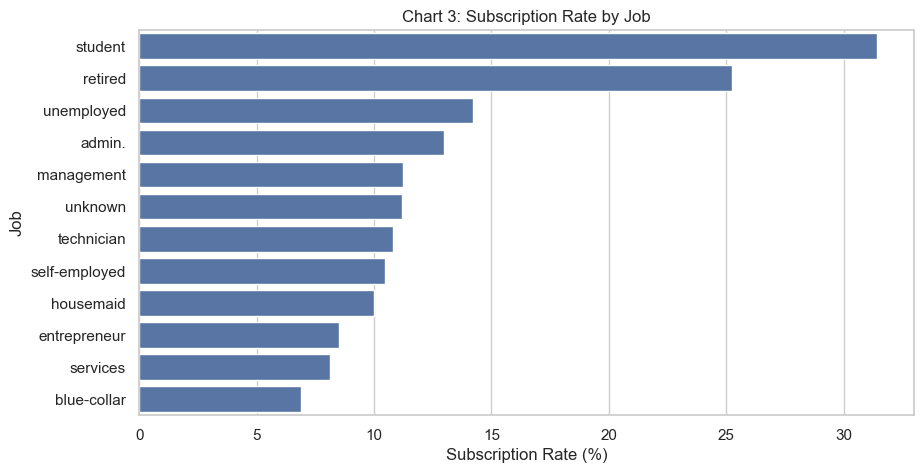

In [15]:
job_subscription_rate = eda_df.groupby("job")["target_yes"].mean().sort_values(ascending=False) * 100

plt.figure(figsize=(10, 5))

sns.barplot(x=job_subscription_rate.values, y=job_subscription_rate.index)

plt.title("Chart 4: Subscription Rate by Job")

plt.xlabel("Subscription Rate (%)")

plt.ylabel("Job")

plt.show()

#### How to Interpret Chart 4

Students and retired clients have the highest subscription rates among job categories.

Blue-collar, services, and entrepreneur categories have lower subscription rates.

This does not prove that job type causes subscription behaviour, but it suggests that job category may be useful for prediction.

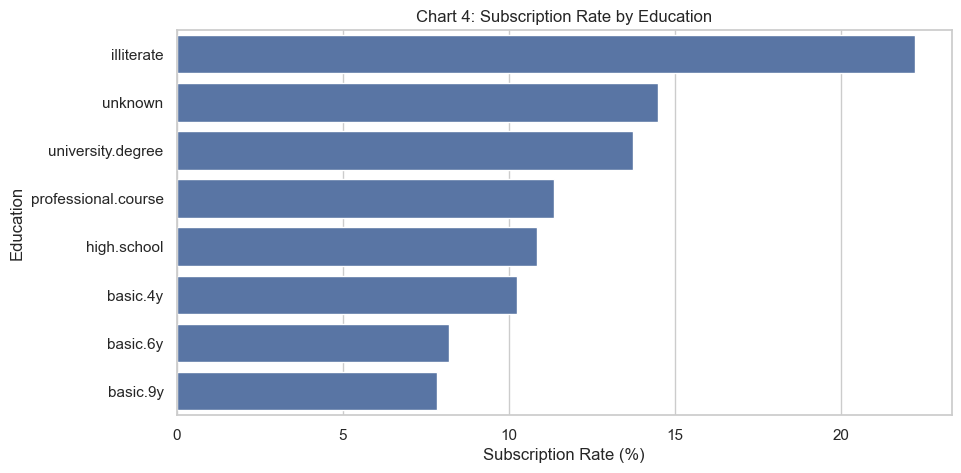

In [16]:
education_subscription_rate = eda_df.groupby("education")["target_yes"].mean().sort_values(ascending=False) * 100

plt.figure(figsize=(10, 5))

sns.barplot(x=education_subscription_rate.values, y=education_subscription_rate.index)

plt.title("Chart 5: Subscription Rate by Education")

plt.xlabel("Subscription Rate (%)")

plt.ylabel("Education")

plt.show()

#### How to Interpret Chart 5

Subscription rates differ across education groups.

`university.degree` and `professional.course` are among the stronger education categories, while some basic education groups have lower rates.

The `unknown` education group also has a noticeable subscription rate, so it should be handled carefully instead of being ignored.

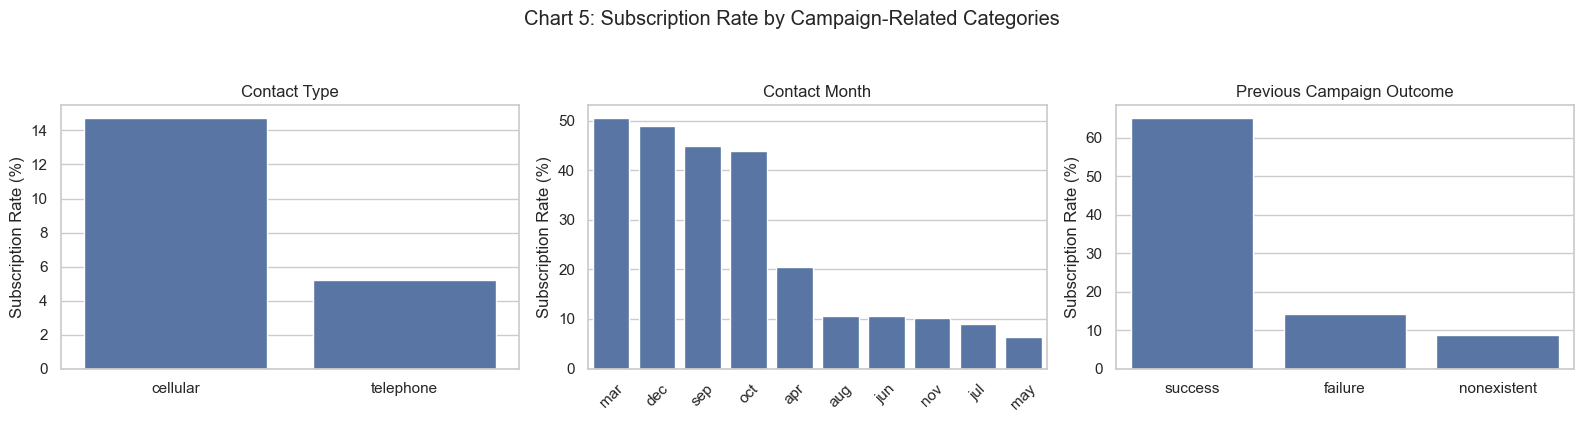

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

contact_rate = eda_df.groupby("contact")["target_yes"].mean().sort_values(ascending=False) * 100

month_rate = eda_df.groupby("month")["target_yes"].mean().sort_values(ascending=False) * 100

poutcome_rate = eda_df.groupby("poutcome")["target_yes"].mean().sort_values(ascending=False) * 100

sns.barplot(x=contact_rate.index, y=contact_rate.values, ax=axes[0])

axes[0].set_title("Contact Type")

axes[0].set_xlabel("")

axes[0].set_ylabel("Subscription Rate (%)")

sns.barplot(x=month_rate.index, y=month_rate.values, ax=axes[1])

axes[1].set_title("Contact Month")

axes[1].set_xlabel("")

axes[1].set_ylabel("Subscription Rate (%)")

axes[1].tick_params(axis="x", rotation=45)

sns.barplot(x=poutcome_rate.index, y=poutcome_rate.values, ax=axes[2])

axes[2].set_title("Previous Campaign Outcome")

axes[2].set_xlabel("")

axes[2].set_ylabel("Subscription Rate (%)")

plt.suptitle("Chart 6: Subscription Rate by Campaign-Related Categories", y=1.05)

plt.tight_layout()

plt.show()

#### How to Interpret Chart 6

Campaign-related variables show clear differences in subscription rates.

- Cellular contact has a higher subscription rate than telephone contact.
- Some months, especially March, December, September, and October, have much higher subscription rates.
- Clients with a previous successful campaign outcome have a much higher subscription rate.

These features appear informative, but they should still be validated during modelling.

In [18]:
additional_categorical = ["marital", "default", "housing", "loan", "day_of_week"]
additional_category_summaries = []

# Build one combined summary table so these categorical features can be compared together.
for column in additional_categorical:
    summary = eda_df.groupby(column).agg(
        count=("target_yes", "size"),
        subscription_rate_percent=("target_yes", "mean")
    ).reset_index()
    
    summary["subscription_rate_percent"] = (summary["subscription_rate_percent"] * 100).round(2)
    summary["feature"] = column
    summary = summary.rename(columns={column: "category"})
    
    additional_category_summaries.append(summary)

additional_category_summary = pd.concat(additional_category_summaries, ignore_index=True)
additional_category_summary[["feature", "category", "count", "subscription_rate_percent"]]

,feature,category,count,subscription_rate_percent
0,marital,divorced,4612,10.32
1,marital,married,24928,10.16
2,marital,single,11568,14.00
3,marital,unknown,80,15.00
4,default,no,32588,12.88
5,default,unknown,8597,5.15
6,default,yes,3,0.00
7,housing,no,18622,10.88
8,housing,unknown,990,10.81
9,housing,yes,21576,11.62


The grouped summary table extends the categorical analysis to `marital`, `default`, `housing`, `loan`, and `day_of_week`.

These variables are worth checking because marital status, credit status, loan ownership, and contact day may all relate to how likely a client is to subscribe.

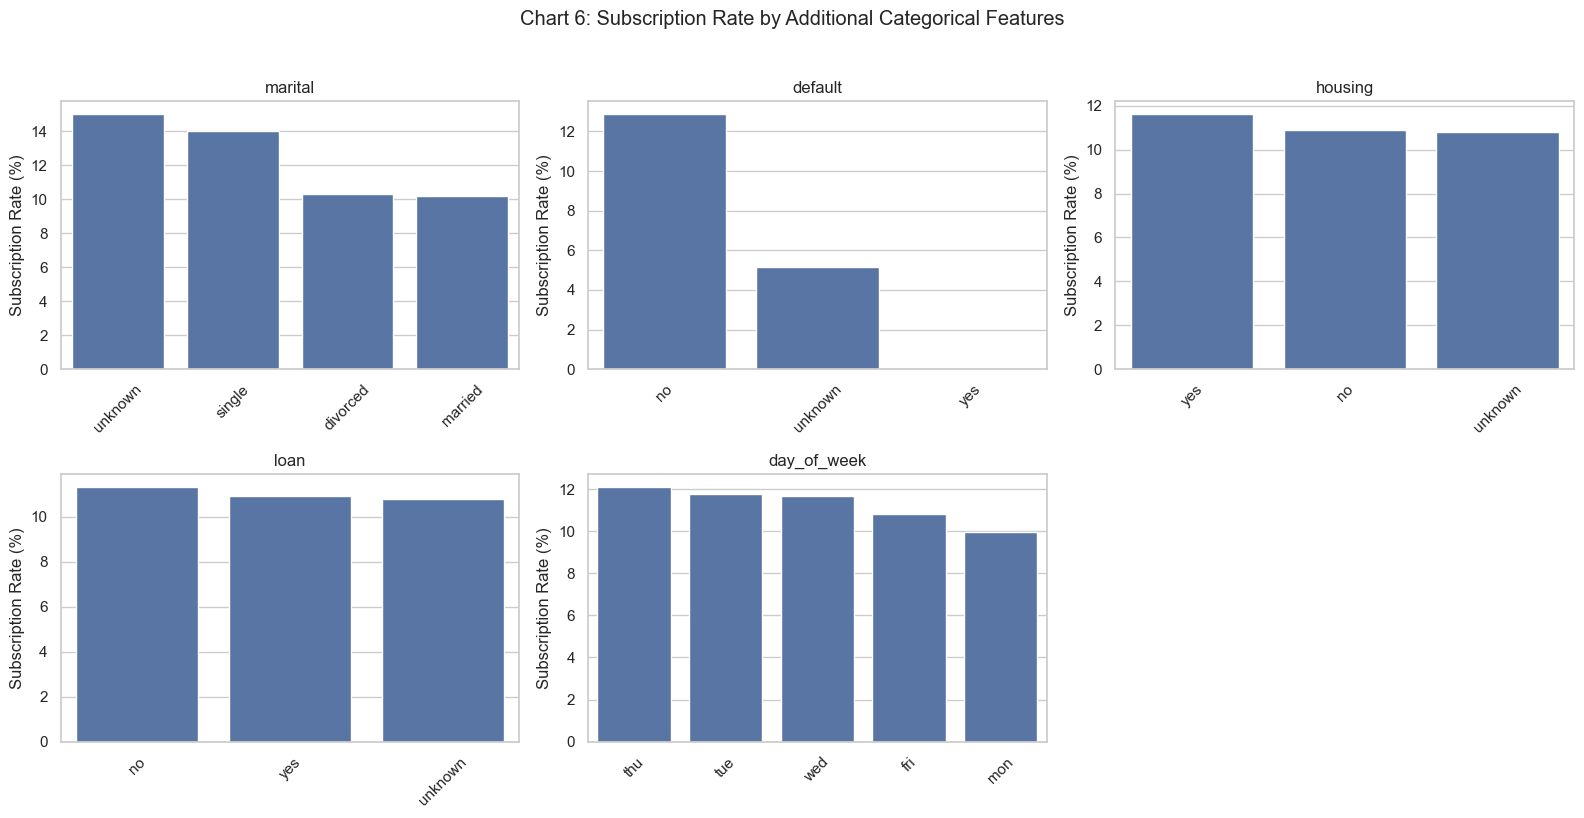

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

# Plot the same subscription-rate view for each additional categorical feature.
for i, column in enumerate(additional_categorical):
    rate = eda_df.groupby(column)["target_yes"].mean().sort_values(ascending=False) * 100
    
    sns.barplot(x=rate.index, y=rate.values, ax=axes[i])
    
    axes[i].set_title(column)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Subscription Rate (%)")
    axes[i].tick_params(axis="x", rotation=45)

axes[-1].remove()

plt.suptitle("Chart 7: Subscription Rate by Additional Categorical Features", y=1.02)
plt.tight_layout()
plt.show()

#### How to Interpret Chart 7

The additional categorical features show smaller but still useful differences in subscription rates.

- `marital` shows that single clients have a higher subscription rate than married or divorced clients.
- `default`, `housing`, and `loan` show differences across financial-status groups, though some categories may be small or contain `unknown` values.
- `day_of_week` does not show as strong a pattern as `month`, but it is still useful to check for possible timing effects.

These variables should be kept as candidate predictors and validated during modelling rather than excluded during EDA.

#### Bivariate Feature Interaction Analysis

In this section, I check whether subscription rates change when two categorical features are considered together.

This is useful because some patterns may only appear through interactions. For example, the effect of a previous campaign outcome may differ depending on the contact type or month.

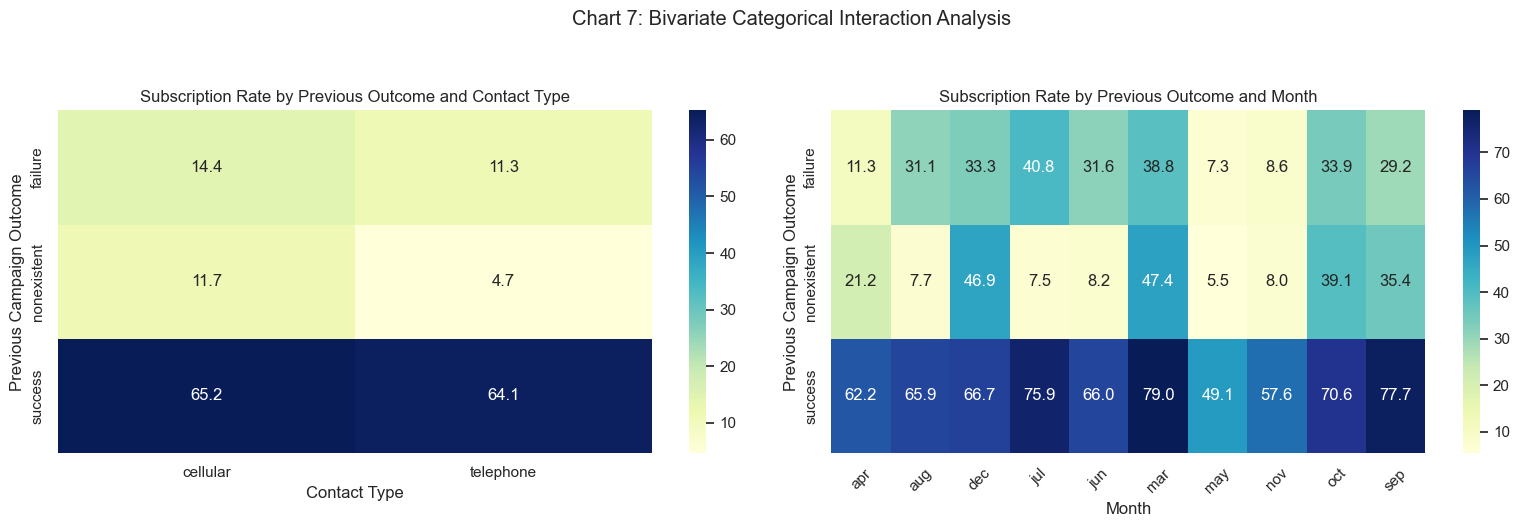

In [20]:
# Create pivot tables to compare how previous campaign outcome interacts with contact type and month.
poutcome_contact_rate = eda_df.pivot_table(
    index="poutcome",
    columns="contact",
    values="target_yes",
    aggfunc="mean"
) * 100

poutcome_month_rate = eda_df.pivot_table(
    index="poutcome",
    columns="month",
    values="target_yes",
    aggfunc="mean"
) * 100

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

sns.heatmap(poutcome_contact_rate, annot=True, fmt=".1f", cmap="Blues", ax=axes[0])
axes[0].set_title("Previous Outcome x Contact Type")
axes[0].set_xlabel("Contact Type")
axes[0].set_ylabel("Previous Outcome")

sns.heatmap(poutcome_month_rate, annot=True, fmt=".1f", cmap="Blues", ax=axes[1])
axes[1].set_title("Previous Outcome x Contact Month")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Previous Outcome")
axes[1].tick_params(axis="x", rotation=45)

plt.suptitle("Chart 8: Subscription Rate Interactions (%)", y=1.05)
plt.tight_layout()
plt.show()

#### How to Interpret Chart 8

The interaction heatmaps show that subscription rates vary across combinations of campaign-related features.

Clients with a previous successful campaign outcome generally have higher subscription rates, but the strength of this pattern differs by contact type and month. This suggests that previous campaign outcome may interact with campaign timing and contact channel.

These interaction patterns are useful for EDA, but they should still be validated during modelling before making final feature decisions.

### Section 5: Statistical Associations and Correlation Review

Visualisations show useful patterns, but statistical tests help check whether the observed differences are likely to be meaningful rather than random variation.

For categorical features, I use chi-squared tests of association against the target. For numerical features, I use the Mann-Whitney U test because several numerical variables are skewed and do not look normally distributed.

In [23]:
categorical_test_features = ["job", "education", "contact", "month", "poutcome", "marital", "default", "housing", "loan", "day_of_week"]
chi_square_results = []

# Run a chi-squared test for each categorical feature and use Cramer's V as a simple effect-size measure.
for column in categorical_test_features:
    contingency_table = pd.crosstab(df[column], df["y"])
    chi2_statistic, p_value, degrees_of_freedom, expected = chi2_contingency(contingency_table)
    
    n = contingency_table.to_numpy().sum()
    min_dimension = min(contingency_table.shape) - 1
    cramers_v = np.sqrt(chi2_statistic / (n * min_dimension))
    
    chi_square_results.append({
        "feature": column,
        "chi2_statistic": chi2_statistic,
        "p_value": p_value,
        "degrees_of_freedom": degrees_of_freedom,
        "cramers_v": cramers_v
    })

chi_square_summary = pd.DataFrame(chi_square_results).sort_values("cramers_v", ascending=False)
chi_square_summary

,feature,chi2_statistic,p_value,degrees_of_freedom,cramers_v
4,poutcome,4230.52,0.00,2,0.32
3,month,3101.15,0.00,9,0.27
0,job,961.24,0.00,11,0.15
2,contact,862.32,0.00,1,0.14
6,default,406.58,0.00,2,0.10
1,education,193.11,0.00,7,0.07
5,marital,122.66,0.00,3,0.06
9,day_of_week,26.14,0.00,4,0.03
7,housing,5.68,0.06,2,0.01
8,loan,1.09,0.58,2,0.01


The chi-squared tests provide statistical support that several categorical variables are associated with the target.

Because the dataset is large, very small p-values are expected for many features. For interpretation, I focus not only on p-values but also on Cramer's V, which gives a simple indication of association strength. Features such as previous campaign outcome, contact type, and month are especially useful to review because they show stronger category-level differences.

In [24]:
numerical_test_features = ["age", "duration", "campaign", "pdays", "previous", "euribor3m"]
mann_whitney_results = []

# Compare each numerical feature between the yes and no groups without assuming a normal distribution.
for column in numerical_test_features:
    no_values = df.loc[df["y"] == "no", column]
    yes_values = df.loc[df["y"] == "yes", column]
    
    statistic, p_value = mannwhitneyu(no_values, yes_values, alternative="two-sided")
    
    mann_whitney_results.append({
        "feature": column,
        "median_no": no_values.median(),
        "median_yes": yes_values.median(),
        "mann_whitney_u": statistic,
        "p_value": p_value
    })

mann_whitney_summary = pd.DataFrame(mann_whitney_results).sort_values("p_value")
mann_whitney_summary

,feature,median_no,median_yes,u_statistic,p_value
1,duration,163.50,449.00,30788443.50,0.00
3,pdays,999.00,999.00,101197910.00,0.00
5,euribor3m,4.86,1.27,126080978.50,0.00
4,previous,0.00,0.00,66257901.50,0.00
2,campaign,2.00,2.00,94153911.50,0.00
0,age,38.00,37.00,86626886.50,0.02


The Mann-Whitney U tests support the visual finding that several numerical variables differ between clients who subscribed and clients who did not.

The median comparison is especially useful because the numerical variables are skewed. `duration` shows a clear difference, but it remains a leakage risk because it may not be available before the call is completed. `pdays` should also be interpreted carefully because 999 is a special value for clients who were not previously contacted.

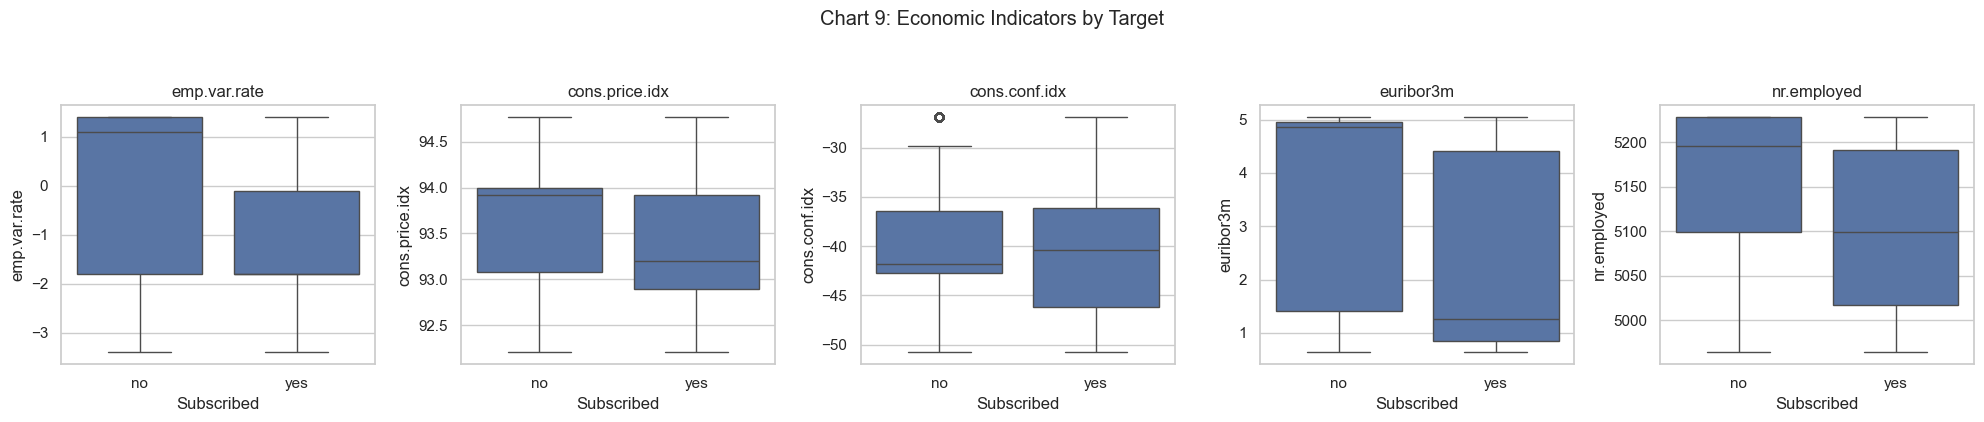

In [25]:
economic_columns = ["emp.var.rate", "cons.price.idx", "cons.conf.idx", "euribor3m", "nr.employed"]
fig, axes = plt.subplots(1, len(economic_columns), figsize=(20, 4))

# Compare all economic indicators against the target using the same boxplot structure.
for i, column in enumerate(economic_columns):
    sns.boxplot(data=df, x="y", y=column, ax=axes[i], order=["no", "yes"])
    axes[i].set_title(column)
    axes[i].set_xlabel("Subscribed")

plt.suptitle("Chart 9: Economic Indicators by Target", y=1.05)
plt.tight_layout()
plt.show()

#### How to Interpret Chart 9

The economic indicators show visible differences between clients who subscribed and clients who did not.

Subscribers tend to appear under different economic conditions, especially for `emp.var.rate`, `euribor3m`, and `nr.employed`. `cons.price.idx` and `cons.conf.idx` also show target-group differences, but the patterns should be interpreted carefully because these indicators are macroeconomic variables and may be correlated with each other.

This supports keeping the economic indicators as candidate predictors while checking their overlap during correlation review and modelling.

In [26]:
df.groupby("y")[economic_columns].mean().round(2)

,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
y,,,,,
no,0.25,93.60,-40.59,3.81,5176.17
yes,-1.23,93.35,-39.79,2.12,5095.12


#### Correlation Review

A correlation heatmap helps identify numerical variables that move together.

This is useful because highly correlated features can make interpretation harder, especially for models where feature effects are reviewed directly.

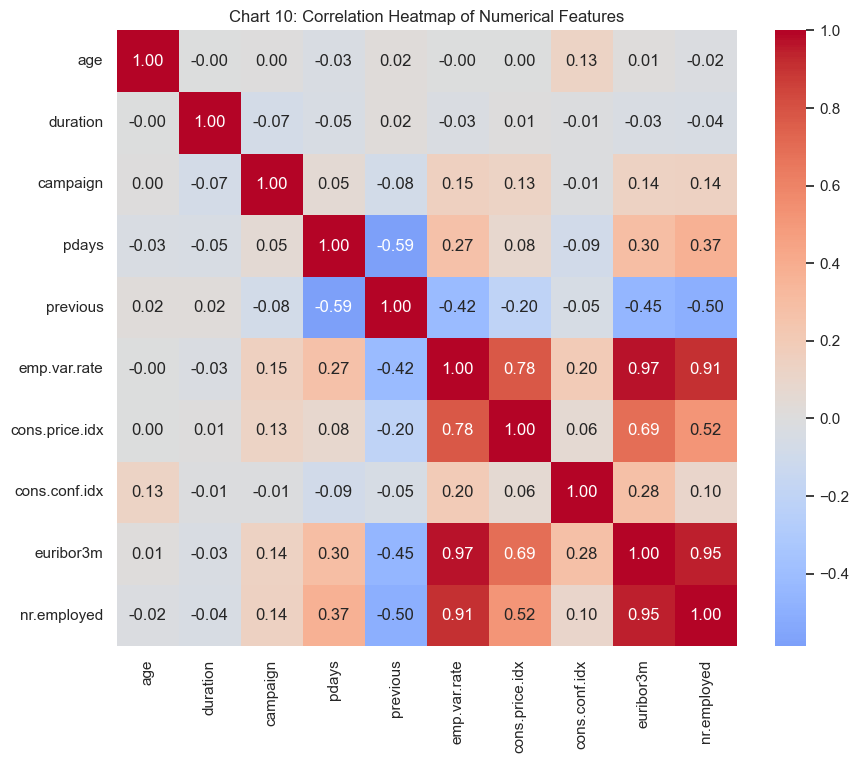

In [27]:
correlation_matrix = df[numeric_columns].corr()

plt.figure(figsize=(10, 8))

sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)

plt.title("Chart 10: Correlation Heatmap of Numerical Features")

plt.show()

#### How to Interpret Chart 10

Several economic variables are strongly correlated.

`emp.var.rate`, `euribor3m`, and `nr.employed` move closely together. This makes sense because they describe related economic conditions.

For modelling, this is not always a problem, especially for tree-based models. However, for interpretation, I should be careful not to overstate the importance of one economic variable when it overlaps strongly with others.

### Section 6: Leakage and Modelling Risks

EDA is not only about finding patterns. It is also about identifying risks that may make a future model unrealistic or misleading.

Two important risks in this dataset are `duration` and `pdays`.

#### Risk 1: `duration`

`duration` is the length of the last contact call.

It is strongly related to the target because clients who subscribe usually stay on the call longer. However, this feature is only known after the call ends.

If the business goal is to predict whether a client will subscribe before making the call, then `duration` would not be available at prediction time. In that case, using it would create data leakage.

**Implication:** I should consider training future models both with and without `duration`, then explain which version matches the real business use case.

#### Risk 2: `pdays = 999`

`pdays` contains the value 999 for most rows.

This value does not behave like a normal number of days. According to the data dictionary, 999 means the client was not previously contacted.

**Implication:** For modelling, I should create a clearer feature such as `was_previously_contacted`, or handle `pdays = 999` separately instead of treating it as a normal continuous value.

### Section 7: Conclusions and Modelling Strategy

The EDA provides the following key findings:

1. **The target is imbalanced.** Only 11.27% of clients subscribed to a term deposit. Accuracy alone can be misleading because a model could predict the majority class (`no`) most of the time and still look accurate while missing many actual subscribers.

2. **There is hidden missingness.** Several categorical columns contain `unknown`, especially `default`, `education`, `housing`, `loan`, `job`, and `marital`.

3. **Some numerical features are skewed and contain outliers.** `duration`, `campaign`, and `previous` have many small values and a few large values. The IQR check also flags high-end outliers, including some older clients in `age`.

4. **`pdays` needs special handling.** The value 999 appears in most records and should be treated as a special case because it means the client was not previously contacted, not that 999 days had passed.

5. **Categorical features and interactions show useful differences in subscription rates.** Job, education, contact type, month, previous outcome, marital status, credit-related variables, and day of week all provide category-level patterns. Interaction checks also suggest that previous campaign outcome may behave differently across contact types and months.

6. **Statistical checks support the visual findings.** Chi-squared tests suggest association between important categorical features and the target, while Mann-Whitney U tests support numerical differences between subscribers and non-subscribers.

7. **Economic variables differ by target and are strongly related to each other.** Direct target comparisons show differences across all five economic indicators, while the correlation heatmap shows that some of these indicators overlap strongly.

8. **`duration` is useful but risky.** It is strongly associated with subscription, but it may not be available before a call is completed.

9. **The EDA suggests several feature-engineering ideas for Task 2.** In addition to creating a `was_previously_contacted` flag from `pdays`, useful candidates include binning `age` into life-stage groups, combining `housing` and `loan` into a broader debt indicator, and encoding `month` cyclically or grouping it into quarters.

#### Modeling Strategy Recommendation for Task 2

For the next task, I would evaluate a small set of models that balance interpretability and predictive performance for this imbalanced binary classification problem.

- **Logistic Regression:** Use this as the baseline model because it is simple, fast, and easy to interpret. It helps confirm whether the preprocessing and feature engineering steps are working correctly.
- **Random Forest Classifier:** Use this as a stronger non-linear model because it can capture interactions between customer, campaign, and economic features without requiring many manual transformations.
- **Gradient Boosted Trees:** Use this as the main high-performance candidate because boosted tree models usually perform well on structured tabular data and can handle non-linear patterns effectively.

Before modelling, I would also test a small set of feature-engineering options suggested by the EDA: a `was_previously_contacted` flag from `pdays`, age-group bins, a combined debt indicator from `housing` and `loan`, and a cyclic or quarter-based encoding of `month`. These should be evaluated through cross-validation in Task 2 rather than assumed to improve performance.

The models should be evaluated with and without `duration` because `duration` may cause data leakage depending on when the prediction is meant to be made. Since the target is imbalanced, model comparison should focus on recall, precision, F1-score, PR-AUC, ROC-AUC, and the confusion matrix instead of accuracy alone.